<a href="https://colab.research.google.com/github/ujjwal8868-pixel/code_alpha_tasks/blob/main/credit_score_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.945
Precision: 0.9325842696629213
Recall: 0.9431818181818182
F1 Score: 0.9378531073446328
ROC-AUC: 0.9448051948051949


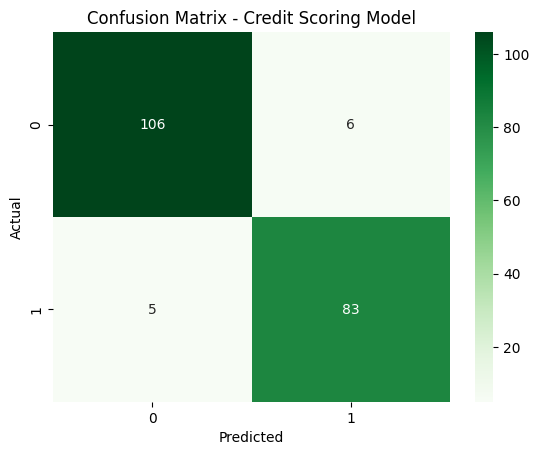

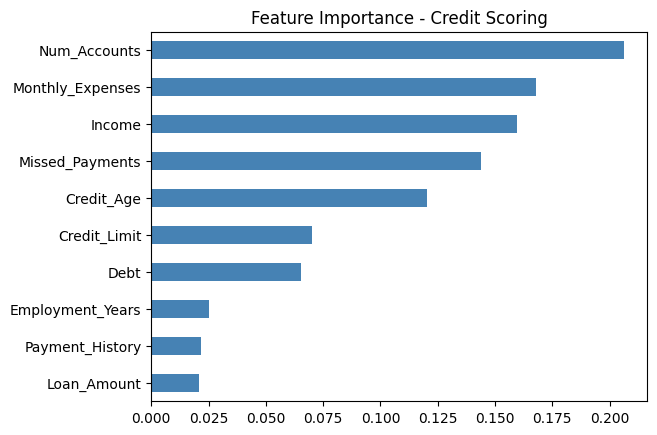

In [ ]:
# Credit Scoring Model using Random Forest
# Dataset: Default of Credit Card Clients

import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic credit data
X, y = make_classification(n_samples=1000, n_features=10,
                            n_informative=5, random_state=42)

feature_names = ['Income', 'Debt', 'Payment_History',
                 'Credit_Age', 'Num_Accounts', 'Missed_Payments',
                 'Credit_Limit', 'Loan_Amount', 'Employment_Years',
                 'Monthly_Expenses']

X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Credit Scoring Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=feature_names)
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Credit Scoring')
plt.show()